Day 9 — Matplotlib Basics

Learn and practice:

matplotlib.pyplot
Figure size
Titles
X/Y labels
Bar charts
Line charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_sales_data.csv")

df.head()

,Item,Quantity,Rate,Value_Without_Tax
0,cl DAZZLE DINNER SET 9 PCS,50.0,1016.10,23649.72
1,cl ROYALE MIXING BOWL 1L,6.0,295.76,887.28
2,cl ROYALE MIXING BOWL I PC SET WLI 1.5L,6.0,380.51,1141.53
3,DAZZLE STELA M MUG 18CL 6PC-NEW,6.0,487.29,1461.87
4,pg HEALTHIFRY+DIGITAL AIR FRYER-19003964,4.0,2538.14,10152.56


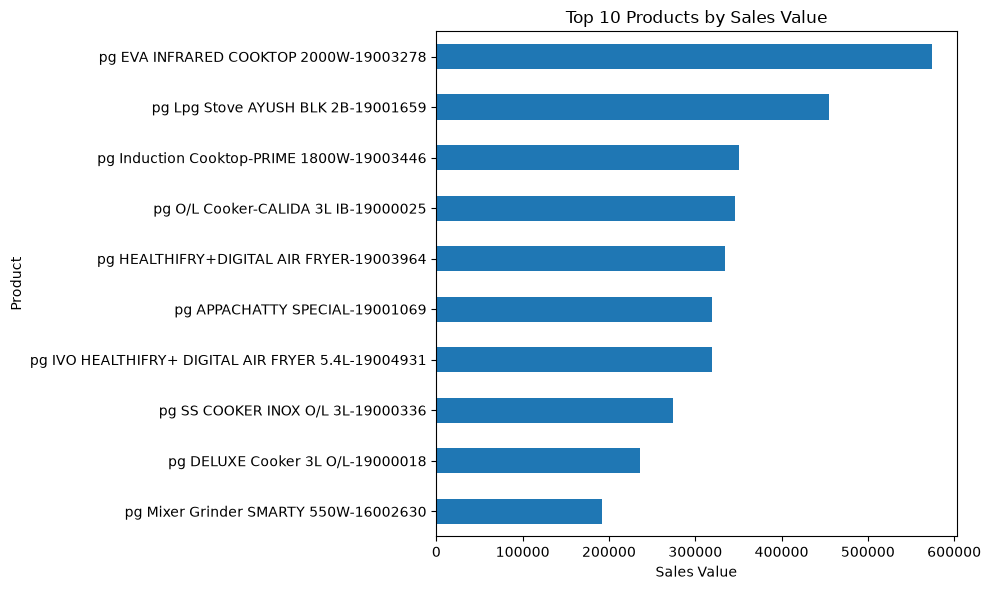

In [2]:
top_sales = (
    df.groupby("Item")["Value_Without_Tax"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sales.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Sales Value")
plt.xlabel("Sales Value")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [3]:
# Seaborn + Histograms

# Install/import Seaborn:

import seaborn as sns

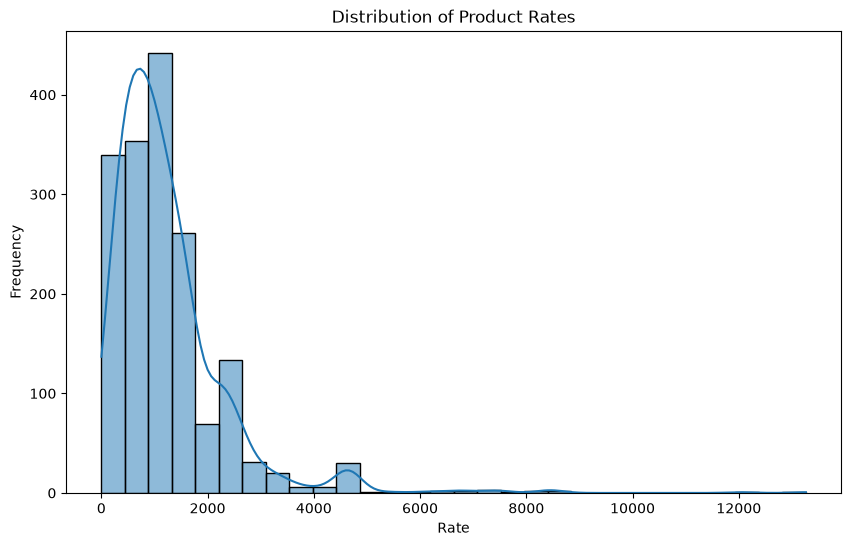

In [4]:
# Create a histogram showing the distribution of product rates:

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Rate",
    bins=30,
    kde=True
)

plt.title("Distribution of Product Rates")
plt.xlabel("Rate")
plt.ylabel("Frequency")
plt.show()

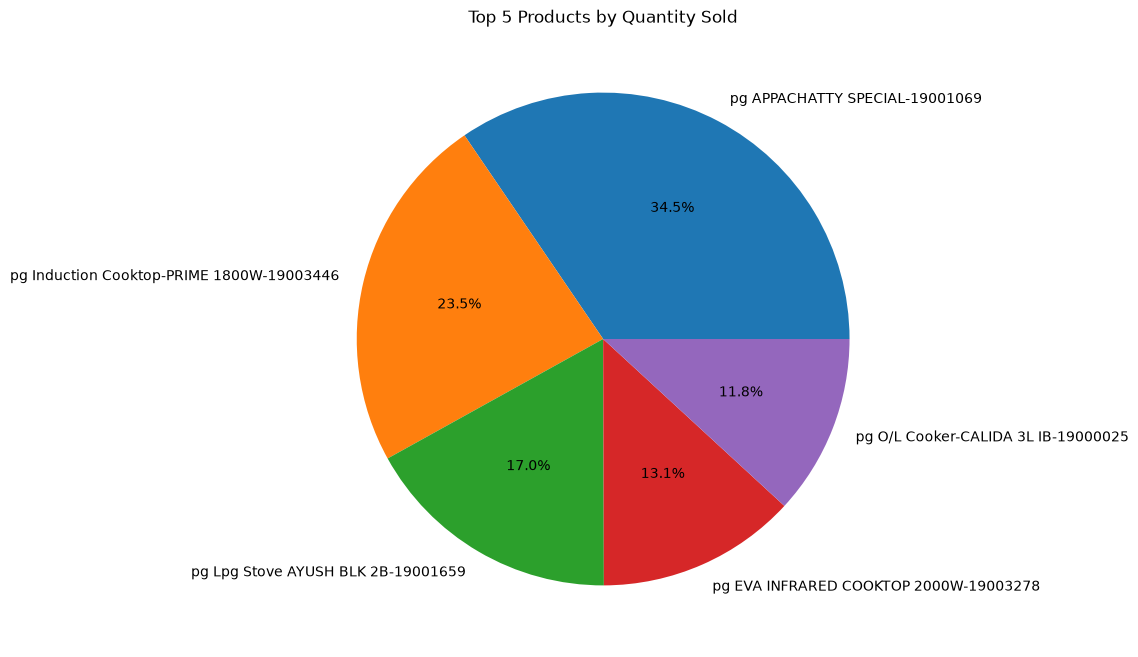

In [6]:
# Pie Chart + Scatter Plot

# For a pie chart, use the top products by quantity:

top_quantity = (
    df.groupby("Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 8))

plt.pie(
    top_quantity.values,
    labels=top_quantity.index,
    autopct="%1.1f%%"
)
plt.title("Top 5 Products by Quantity Sold")
plt.show()

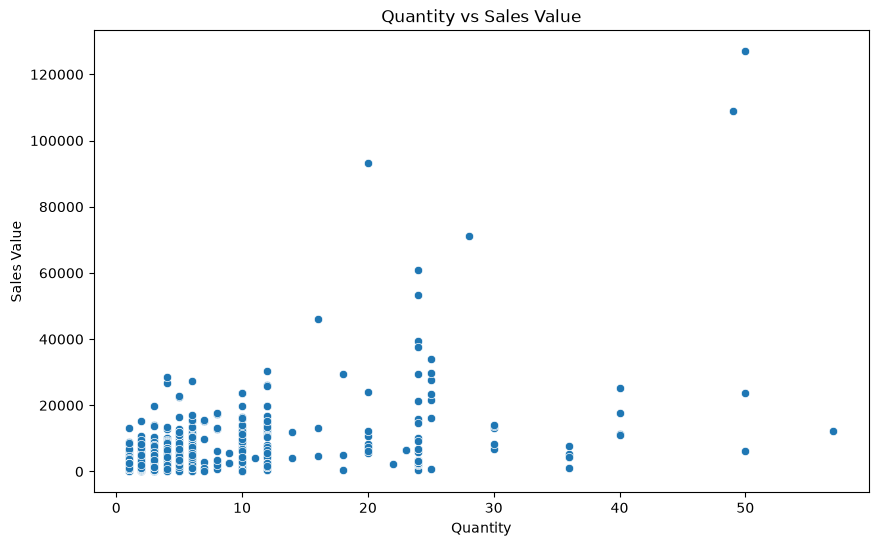

In [7]:
# scatter plot:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Value_Without_Tax"
)

plt.title("Quantity vs Sales Value")
plt.xlabel("Quantity")
plt.ylabel("Sales Value")
plt.show()

Final Visualization Dashboard/Notebook

Your final notebook should contain at least these 5 required chart types:

Chart	What you'll visualize
📊 Bar Chart	Top 10 products by sales
📈 Line Chart	Sales trend
🥧 Pie Chart	Top 5 product quantity share
📉 Histogram	Distribution of product rates
🔵 Scatter Plot	Quantity vs sales value

In [10]:

df_original =pd.read_excel("ss.xlsx")


In [11]:
import pandas as pd

df_original = pd.read_excel(
    "ss.xlsx",
    sheet_name="Sales Register",
    header=3
)

df_original.columns = [
    "Date",
    "Item",
    "Bill_No",
    "Payment_Terms",
    "Quantity",
    "Rate",
    "Value_Without_Tax",
    "Gross_Total",
    "CGST",
    "SGST",
    "Round_Off"
]

df_original.head()

,Date,Item,Bill_No,Payment_Terms,Quantity,Rate,Value_Without_Tax,Gross_Total,CGST,SGST,Round_Off
0,2026-07-01,SHOP NAME,0000-1,01 DAY,50.0,NaN,23649.72,27907.0,2128.47,2128.47,0.34
1,NaT,cl DAZZLE DINNER SET 9 PCS,NaN,NaN,50.0,1016.10,23649.72,NaN,NaN,NaN,NaN
2,2026-07-01,party name,0054/0000-1,30 Days,18.0,NaN,3490.68,4119.0,314.17,314.17,0.02
3,NaT,cl ROYALE MIXING BOWL 1L,NaN,NaN,6.0,295.76,887.28,NaN,NaN,NaN,NaN
4,NaT,cl ROYALE MIXING BOWL I PC SET WLI 1.5L,NaN,NaN,6.0,380.51,1141.53,NaN,NaN,NaN,NaN


In [12]:
invoice_data = df_original[
    df_original["Date"].notna() &
    df_original["Gross_Total"].notna()
].copy()

invoice_data.head()

,Date,Item,Bill_No,Payment_Terms,Quantity,Rate,Value_Without_Tax,Gross_Total,CGST,SGST,Round_Off
0,2026-07-01,SHOP NAME,0000-1,01 DAY,50.0,NaN,23649.72,27907.0,2128.47,2128.47,0.34
2,2026-07-01,party name,0054/0000-1,30 Days,18.0,NaN,3490.68,4119.0,314.17,314.17,0.02
6,2026-07-01,party name,0055/0000-1,30 Days,18.0,NaN,23085.34,25945.0,1429.85,1429.85,0.04
10,2026-07-01,party name,0056/0000-1,30 Days,9.0,NaN,13008.47,15350.0,1170.77,1170.77,0.01
14,2026-07-01,party name,0057/0000-1,30 Days,4.0,NaN,4898.38,5595.0,348.32,348.32,0.02


In [13]:
invoice_data["Date"] = pd.to_datetime(
    invoice_data["Date"],
    errors="coerce"
)

daily_sales = (
    invoice_data.groupby("Date")["Gross_Total"]
    .sum()
    .sort_index()
)

daily_sales.head()

Date
2026-07-01    374699.0
2026-07-02      8371.0
2026-07-03    162229.0
2026-07-04       684.0
2026-07-05      4695.0
Name: Gross_Total, dtype: float64

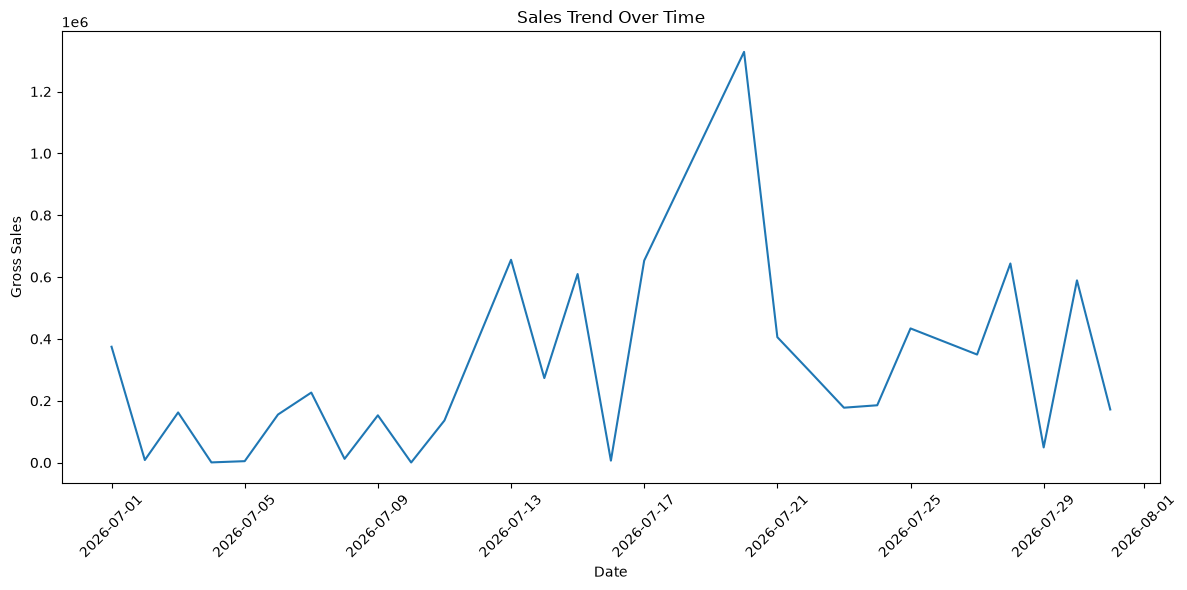

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Gross Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()